In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Loading dataset from sklearn as DataFrame for analying.
diabetes_bunch = load_diabetes(as_frame=True)
diabetes = diabetes_bunch.frame

# No missing values in dataset.
diabetes.isnull().sum()
diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


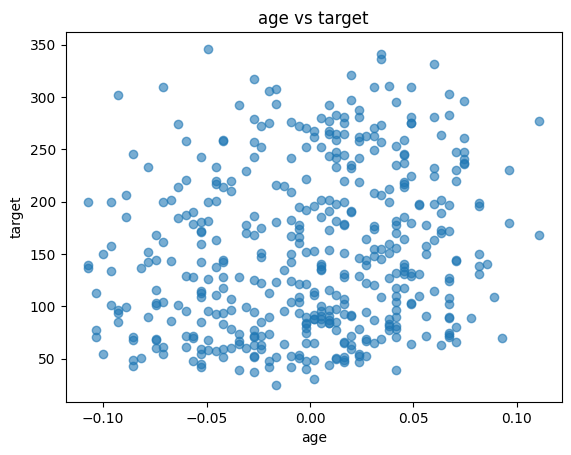

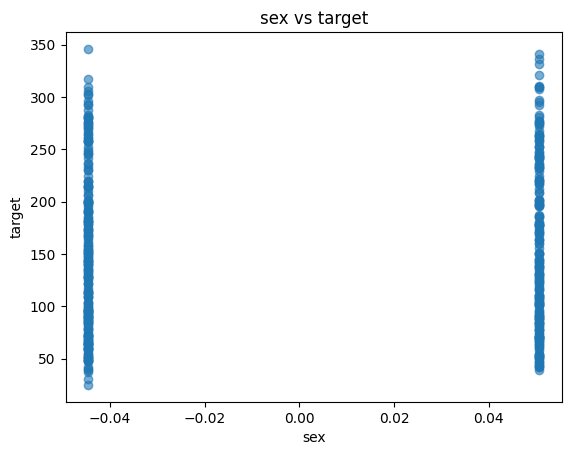

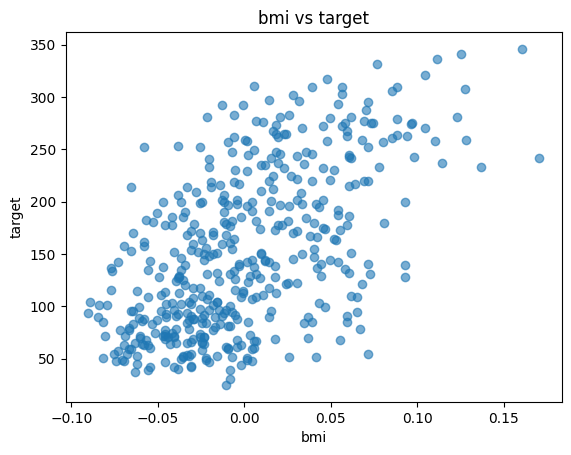

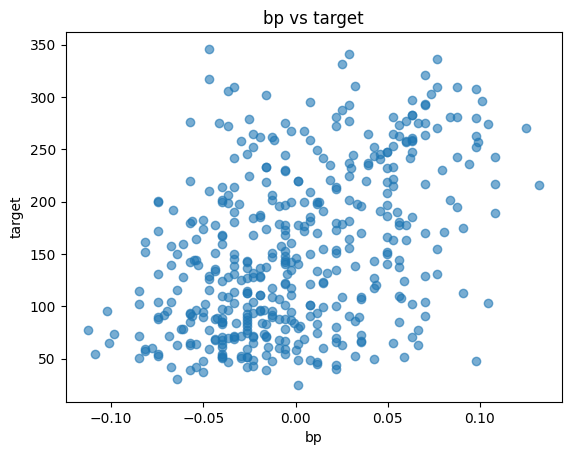

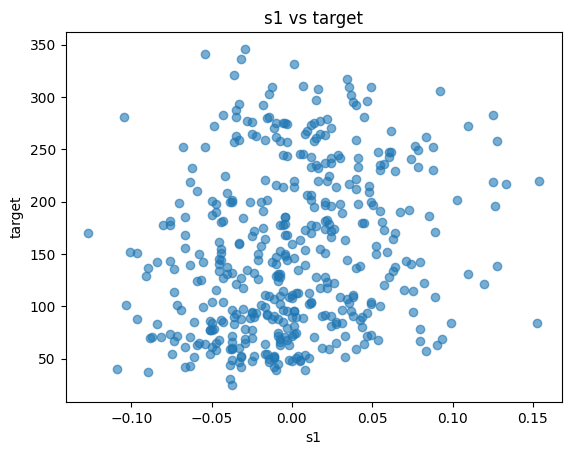

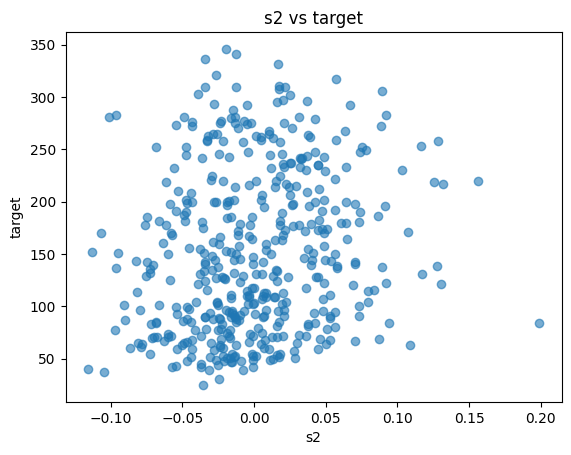

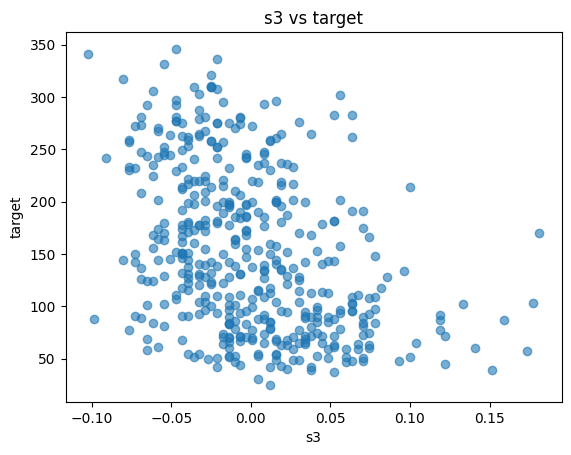

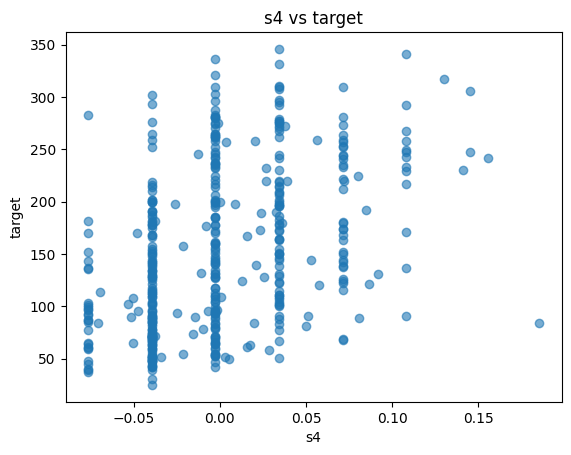

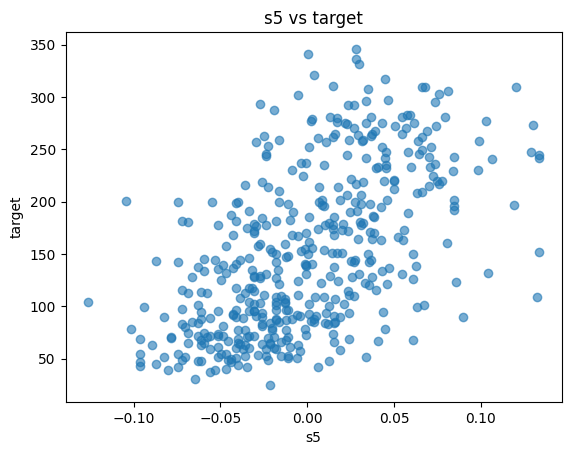

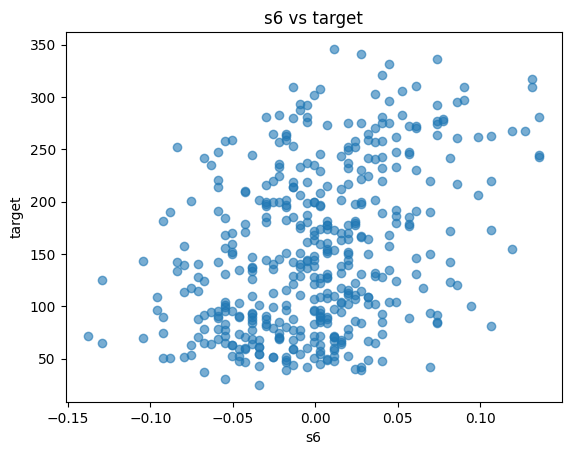

In [5]:
# Making a scatter plot for visualization.
features = diabetes.columns.drop('target')

for col in features:
    plt.figure()
    plt.scatter(diabetes[col], diabetes['target'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('target')
    plt.title(f'{col} vs target')
    plt.show()


In [6]:
# Computing the correlation for each variables against the target.
for col in features:
    corr = diabetes[col].corr(diabetes['target'])
    print(col, corr)

age 0.18788875071891986
sex 0.043061998451605396
bmi 0.5864501344746886
bp 0.44148175856257105
s1 0.21202248101455073
s2 0.17405358696874257
s3 -0.39478925067091836
s4 0.4304528847447731
s5 0.565882592442744
s6 0.382483484248581


In [7]:
# Picking highest correlation features for the model.(bmi, s5)
X = diabetes[['bmi', 'bp', 's4', 's5']]
y = diabetes['target']

# Making tran-test split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=0)

# Training Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# predict results for test data
pred = lin_reg.predict(X_test)

# Drawing a regression line.


# calculate MSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"RMSE: {rmse:.2f}")

print("Train R^2:", lin_reg.score(X_train, y_train))
print("Test R^2:", lin_reg.score(X_test, y_test))

RMSE: 58.33
Train R^2: 0.5107542525423157
Test R^2: 0.336503871521999


In [8]:
# Using polynomial regression
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train,y_train)

poly_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
print(f"RMSE: {rmse:.2f}")

print("Train R^2:", pipeline.score(X_train, y_train))
print("Test R^2:", pipeline.score(X_test, y_test))

RMSE: 57.96
Train R^2: 0.5285533644601152
Test R^2: 0.34482696031292803
